In [90]:

import pandas as pd
import numpy as np
import random
import requests
from zipfile import ZipFile
from io import BytesIO
import matplotlib.pyplot as plt


In [2]:
response = requests.get(
    'https://www.kaggle.com/api/v1/datasets/download/ahmadrazakashif/bmw-worldwide-sales-records-20102024',
)

with open('bmw.zip', 'wb') as f:
    f.write(response.content)

In [3]:
zf = ZipFile('bmw.zip', 'r')
print(dir(zf)) # metody ZipFile

zf.namelist()

['NameToInfo', '_RealGetContents', '__class__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_allowZip64', '_comment', '_didModify', '_extract_member', '_filePassed', '_fileRefCnt', '_fpclose', '_lock', '_open_to_write', '_sanitize_windows_name', '_seekable', '_strict_timestamps', '_windows_illegal_name_trans_table', '_write_end_record', '_writecheck', '_writing', 'close', 'comment', 'compression', 'compresslevel', 'debug', 'extract', 'extractall', 'filelist', 'filename', 'fp', 'getinfo', 'infolist', 'metadata_encoding', 'mkdir', 'mode', 'namelist', 'open', 'printdir', 'pwd', 'read', 'setpassword', 'start_dir', 'testzip', 'write', 'writestr']


['BMW sales data (2010-2024) (1).csv']

In [74]:
# mozemy uzyć do zapisu na dysk
# zf.extractall('bmw')
# zf.close()


In [4]:
df_bmw=pd.read_csv(BytesIO(zf.read('BMW sales data (2010-2024) (1).csv')))

In [5]:

# zaawansowane filtrowanie danych
df_bmw[(df_bmw['Year'].astype(str).str.contains('|'.join(['2016', '2017']),na=False)) & df_bmw['Color'].str.contains('|'.join(['Red', 'Blue']),na=False) ]


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
11,i8,2016,North America,Blue,Hybrid,Manual,1.9,116863,74539,8252,High
17,M5,2017,North America,Red,Diesel,Automatic,2.6,86900,81934,9755,High
134,X5,2017,South America,Red,Petrol,Automatic,4.3,169491,40275,8394,High
137,X6,2017,South America,Red,Hybrid,Manual,1.9,111235,39627,3147,Low
...,...,...,...,...,...,...,...,...,...,...,...
49940,X6,2017,Europe,Blue,Electric,Automatic,2.6,80211,63645,4623,Low
49945,X3,2016,Middle East,Blue,Electric,Manual,3.2,16968,36532,964,Low
49947,X5,2016,Europe,Red,Petrol,Automatic,3.7,167834,55307,3258,Low
49948,X3,2017,Middle East,Red,Hybrid,Automatic,1.5,168069,36683,1545,Low


In [6]:
#pip install -U pandasql
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

In [7]:
#ciekwe i uzytczne ale uwaga na indexy rekordow....
pysqldf ('''
SELECT * FROM df_bmw 
where 
(Year='2016' or Year='2017')
and 
(Color='Red' or Color='Blue')
''')


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2016,North America,Blue,Hybrid,Manual,1.9,116863,74539,8252,High
2,M5,2017,North America,Red,Diesel,Automatic,2.6,86900,81934,9755,High
3,X5,2017,South America,Red,Petrol,Automatic,4.3,169491,40275,8394,High
4,X6,2017,South America,Red,Hybrid,Manual,1.9,111235,39627,3147,Low
...,...,...,...,...,...,...,...,...,...,...,...
2120,X6,2017,Europe,Blue,Electric,Automatic,2.6,80211,63645,4623,Low
2121,X3,2016,Middle East,Blue,Electric,Manual,3.2,16968,36532,964,Low
2122,X5,2016,Europe,Red,Petrol,Automatic,3.7,167834,55307,3258,Low
2123,X3,2017,Middle East,Red,Hybrid,Automatic,1.5,168069,36683,1545,Low


In [8]:
df_bmw.Region.unique()

array(['Asia', 'North America', 'Middle East', 'South America', 'Europe',
       'Africa'], dtype=object)

In [9]:
pysqldf ('''
SELECT DISTINCT(Region) FROM df_bmw 

''')

,Region
0,Asia
1,North America
2,Middle East
3,South America
4,Europe
5,Africa


In [10]:
pysqldf ('''
SELECT * FROM df_bmw 
WHERE Model like 'i%' 
and (Fuel_Type='Petrol' or Fuel_Type='Disel')

''' )

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,i8,2010,Middle East,Grey,Petrol,Automatic,4.0,98514,37949,2278,Low
1,i3,2024,Middle East,Red,Petrol,Automatic,3.5,135958,69578,173,Low
2,i3,2023,North America,Silver,Petrol,Automatic,4.9,94453,79039,8283,High
3,i8,2013,Middle East,White,Petrol,Manual,3.1,42427,44269,5887,Low
4,i3,2018,South America,Red,Petrol,Manual,4.1,1428,46127,608,Low
...,...,...,...,...,...,...,...,...,...,...,...
2311,i8,2010,Africa,Grey,Petrol,Automatic,1.7,108211,109030,9243,High
2312,i3,2020,Middle East,Blue,Petrol,Automatic,4.2,31961,56614,2442,Low
2313,i3,2018,North America,Black,Petrol,Automatic,4.9,23415,71634,7804,High
2314,i8,2014,Africa,Grey,Petrol,Automatic,4.6,50378,98930,1779,Low


In [11]:
index_to_drop=df_bmw[(df_bmw['Model'].str.startswith('i')) \
    & df_bmw['Fuel_Type'].str.contains('|'.join(['Petrol', 'Disel']),na=False) ].index.to_list()


In [12]:

df_bmw_modyfied=df_bmw.drop(df_bmw.index[index_to_drop]).reset_index(drop=True) #porównać indexy z sql z df_bmw
df_bmw_modyfied

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
47679,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
47680,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
47681,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
47682,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [13]:
df_bmw_modyfied.Model.unique()

array(['5 Series', 'i8', 'X3', '7 Series', 'M5', '3 Series', 'X1', 'M3',
       'X5', 'X6', 'i3'], dtype=object)

In [14]:
for model in df_bmw_modyfied.Model.unique():
    print(model, 
    df_bmw_modyfied[df_bmw_modyfied['Model']==model].Year.min(), 
    df_bmw_modyfied[df_bmw_modyfied['Model']==model].Year.max())

5 Series 2010 2024
i8 2010 2024
X3 2010 2024
7 Series 2010 2024
M5 2010 2024
3 Series 2010 2024
X1 2010 2024
M3 2010 2024
X5 2010 2024
X6 2010 2024
i3 2010 2024


In [ ]:
# sgl_1=pysqldf ("SELECT id AS pacjent, count( id) AS id_count, sum(czas),\
# COUNT(DISTINCT CASE WHEN id IS NULL THEN 1 ELSE null END)\
#          FROM df\
#          GROUP BY id\
#          HAVING id_count=4\
#          ORDER BY id_count DESC ;" )
# sgl_1

In [15]:
dates_veryfication=pd.read_csv('perpexity_dates_bmw_helper.csv')
dates_veryfication['launch_year']=dates_veryfication['launch_year'].\
                                str.replace('early ','').str.replace('late ','').\
                                str.replace('(production start in South Africa)','').str.replace('s','').\
                                str.replace('(approx)','').str.strip().astype(int)
dates_veryfication.groupby(['model','region']).agg({'launch_year':'min'}).unstack()                                                  
#uwaga na błędy - większość przypadkówto nie parsowany object (string) na odpowiedni typ danych


launch_year                                                         \
region        Africa    Asia Asia (India)  Europe Middle East North America   
model                                                                         
3 Series         NaN  1970.0          NaN  1970.0      1970.0        1970.0   
5 Series         NaN  2023.0          NaN  2023.0         NaN        2023.0   
7 Series         NaN  2019.0          NaN  2019.0         NaN        2019.0   
M3               NaN  2025.0          NaN  2025.0         NaN        2025.0   
M5               NaN  2017.0          NaN  2017.0      2017.0        2017.0   
X1               NaN  2009.0          NaN  2009.0         NaN        2009.0   
X3            2024.0  2024.0          NaN  2024.0         NaN        2024.0   
X5               NaN  2000.0          NaN  2000.0         NaN        2000.0   
X6               NaN  2000.0          NaN  2000.0         NaN        2000.0   
i3               NaN  2013.0          NaN  2013.0         NaN        2013.0   
i8               NaN  2014.0       2015.0  2014.0         NaN        2014.0   

                        
region   South America  
model                   
3 Series        1970.0  
5 Series           NaN  
7 Series           NaN  
M3                 NaN  
M5              2017.0  
X1                 NaN  
X3                 NaN  
X5                 NaN  
X6                 NaN  
i3                 NaN  
i8                 NaN

In [16]:
bmw_start_of_production=pd.read_csv('bmw_start_of_production.csv')
bmw_start_of_production['start_of_production_year']=bmw_start_of_production['start_of_production_year'].\
                                astype(int)
bmw_start_of_production

,model,start_of_production_year,notes
0,5 Series,1973,First production started Sept 1973 at Dingolfi...
1,i8,2014,Production began spring 2014-ended June 2020
2,X3,2003,First gen production began 2003 (Magna Steyr A...
3,7 Series,1977,Production started in Dingolfing in 1977
4,M5,1984,First M5 produced late 1984 (E28 chassis)
5,3 Series,1975,First gen production began 1975 (E21)
6,X1,2009,First gen production began 2009
7,M3,1986,First M3 production began March 1986 (E30 gene...
8,X5,1999,First X5 launched and produced around late 1999
9,X6,2008,First production started in 2008


In [17]:
df_bmw_modyfied['Model'].isin(bmw_start_of_production['model']).sum()-len(df_bmw_modyfied)

np.int64(0)

In [18]:
for model in bmw_start_of_production['model']:
    df_bmw_modyfied.loc[df_bmw_modyfied['Model']==model,'start_of_production_year']=bmw_start_of_production.\
                loc[bmw_start_of_production['model']==model,'start_of_production_year'].values[0].astype(int)

In [19]:
df_final=df_bmw_modyfied[
    (df_bmw_modyfied['Year']>=df_bmw_modyfied['start_of_production_year'])&
    ~((df_bmw_modyfied['Model']=='i8')& (df_bmw_modyfied['Year']>=2020))&
    ~((df_bmw_modyfied['Model']=='i3')& (df_bmw_modyfied['Year']>=2022))
].reset_index(drop=True)

In [20]:
df_final=df_final.drop('start_of_production_year',axis=1)


In [21]:
# zakladam, ze to moze prawda? :)
df_final['Sales_Classification'].value_counts()

Sales_Classification
Low     30738
High    13490
Name: count, dtype: int64

In [22]:
df_final.groupby(['Year', 'Model'])['Price_USD'].mean().round(0).to_frame(name='average_price_usd_2020').reset_index()


,Year,Model,average_price_usd_2020
0,2010,3 Series,75496.0
1,2010,5 Series,73764.0
2,2010,7 Series,76126.0
3,2010,M3,75610.0
4,2010,M5,73110.0
...,...,...,...
145,2024,M5,72393.0
146,2024,X1,75473.0
147,2024,X3,76453.0
148,2024,X5,73870.0


In [23]:
bmw_prices=pd.read_csv('Model-AveragePrice2020USDapprox-Notes.csv')

In [24]:
bmw_prices[['min_price_usd_2020', 'max_price_usd_2020']]=bmw_prices['Average Price 2020 (USD approx)'].str.replace('Approx $', '').\
     str.replace(',', '').str.replace('$', '').str.split('-', expand=True)
bmw_prices['min_price_usd_2020']=bmw_prices['min_price_usd_2020'].astype(int)
bmw_prices['max_price_usd_2020']=bmw_prices['max_price_usd_2020'].astype(int)
bmw_prices

,Model,Average Price 2020 (USD approx),Notes,min_price_usd_2020,max_price_usd_2020
0,5 Series,"$30,000 - $38,000",Used market value range based on condition,30000,38000
1,i8,"Approx $140,000 - $160,000",New and used prices vary,140000,160000
2,X3,"Approx $40,000 - $45,000",Varies by trim and condition,40000,45000
3,7 Series,"Approx $85,000 - $100,000",Luxury sedan pricing,85000,100000
4,M5,"Approx $105,000 - $115,000",High-performance model pricing,105000,115000
5,3 Series,"Approx $35,000 - $40,000",Entry luxury sedan,35000,40000
6,X1,"Approx $35,000 - $40,000",Compact luxury SUV,35000,40000
7,M3,"Approx $70,000 - $80,000",Performance sedan,70000,80000
8,X5,"Approx $55,000 - $60,000",Mid-size luxury SUV,55000,60000
9,X6,"Approx $60,000 - $70,000",Sporty SUV coupe,60000,70000


In [25]:
for i in range(len(df_final)):
    model=df_final.iloc[i,:]['Model']
    df_final.loc[i,'average_price_usd_2020']=np.random.randint(bmw_prices[bmw_prices['Model']==model]['min_price_usd_2020'], 
    bmw_prices[bmw_prices['Model']==model]['max_price_usd_2020'])


In [26]:
#sprawdzamy podmiane danych
for model in df_final['Model'].unique():
    print(model, df_final[df_final['Model']==model]['average_price_usd_2020'].min(),\
         df_final[df_final['Model']==model]['average_price_usd_2020'].max())


5 Series 30001.0 37999.0
X3 40000.0 44999.0
7 Series 85004.0 99999.0
M5 105002.0 114998.0
i8 140015.0 159969.0
3 Series 35003.0 39997.0
X1 35000.0 39998.0
M3 70008.0 79999.0
X5 55000.0 59998.0
X6 60000.0 69999.0
i3 40003.0 44996.0


In [27]:
# dane mało wiarygodne - zobaczny jak wyglada produkcja :
df_final.groupby(['Year','Model'])['Sales_Volume'].sum().to_frame(name='Sales_Volume').reset_index()


,Year,Model,Sales_Volume
0,2010,3 Series,1647769
1,2010,5 Series,1501229
2,2010,7 Series,1388037
3,2010,M3,1523792
4,2010,M5,1594989
...,...,...,...
145,2024,M5,1632996
146,2024,X1,1493734
147,2024,X3,1664449
148,2024,X5,1458678


In [28]:
average_production=pd.read_csv('production_average.csv')
average_production

,model,calculation,region,average_production,data_source
0,5 Series,average,Global,30000-60000,BMW sales data and reports ​
1,i8,production run,Global,19000-21000,BMW production reports ​
2,X3,average,Global,120000-160000,BMW sales data ​
3,7 Series,average,Global,20000-30000,BMW sales reports ​
4,M5,average,Global,9500-10000,BMW niche model production ​
5,3 Series,average,Global,200000-250000,BMW best-selling model data ​
6,X1,average,Global,70000-90000,BMW sales data ​
7,M3,average,Global,10000-15000,BMW performance model data ​
8,X5,average,Global,125000-150000,BMW SUV sales data ​
9,X6,average,Global,50000-70000,BMW X6 sales data ​


In [29]:
average_production['min_production']=average_production['average_production'].str.split('-').str[0].astype(int)
average_production['max_production']=average_production['average_production'].str.split('-').str[1].astype(int)

In [30]:
# czy to wlasciwe podejcie, dlaczego tak dlaczego nie (perspektywa biznesu i analizy)
for i in range(len(df_final)):
    model=df_final.iloc[i,:]['Model']
    df_final.loc[i,'average_sale']=np.random.randint(average_production[average_production['model']==model]['min_production'], 
    average_production[average_production['model']==model]['max_production'])


In [36]:
# for model in df_final['Model'].unique():
#     print(model,df_final[df_final['Model']==model].groupby(['Year', 'Region'])['Model'].count().to_frame(name='number_of_sales').reset_index())
df_final.groupby(['Year', 'Region', 'Model'])['Model'].count().to_frame(name='number_of_sales').reset_index()

,Year,Region,Model,number_of_sales
0,2010,Africa,3 Series,60
1,2010,Africa,5 Series,55
2,2010,Africa,7 Series,53
3,2010,Africa,M3,43
4,2010,Africa,M5,38
...,...,...,...,...
895,2024,South America,M5,40
896,2024,South America,X1,49
897,2024,South America,X3,50
898,2024,South America,X5,42


In [37]:
bmw_prices

,Model,Average Price 2020 (USD approx),Notes,min_price_usd_2020,max_price_usd_2020
0,5 Series,"$30,000 - $38,000",Used market value range based on condition,30000,38000
1,i8,"Approx $140,000 - $160,000",New and used prices vary,140000,160000
2,X3,"Approx $40,000 - $45,000",Varies by trim and condition,40000,45000
3,7 Series,"Approx $85,000 - $100,000",Luxury sedan pricing,85000,100000
4,M5,"Approx $105,000 - $115,000",High-performance model pricing,105000,115000
5,3 Series,"Approx $35,000 - $40,000",Entry luxury sedan,35000,40000
6,X1,"Approx $35,000 - $40,000",Compact luxury SUV,35000,40000
7,M3,"Approx $70,000 - $80,000",Performance sedan,70000,80000
8,X5,"Approx $55,000 - $60,000",Mid-size luxury SUV,55000,60000
9,X6,"Approx $60,000 - $70,000",Sporty SUV coupe,60000,70000


In [38]:
bmw_start_of_production

,model,start_of_production_year,notes
0,5 Series,1973,First production started Sept 1973 at Dingolfi...
1,i8,2014,Production began spring 2014-ended June 2020
2,X3,2003,First gen production began 2003 (Magna Steyr A...
3,7 Series,1977,Production started in Dingolfing in 1977
4,M5,1984,First M5 produced late 1984 (E28 chassis)
5,3 Series,1975,First gen production began 1975 (E21)
6,X1,2009,First gen production began 2009
7,M3,1986,First M3 production began March 1986 (E30 gene...
8,X5,1999,First X5 launched and produced around late 1999
9,X6,2008,First production started in 2008


In [44]:
pysqldf ('''
SELECT a.*, b.* FROM bmw_prices AS a 
LEFT JOIN
(SELECT 
*
FROM bmw_start_of_production 
) AS b 
ON a.Model=b.model 
WHERE b.notes like '%First%'
''')

,Model,Average Price 2020 (USD approx),Notes,min_price_usd_2020,max_price_usd_2020,model,start_of_production_year,notes
0,5 Series,"$30,000 - $38,000",Used market value range based on condition,30000,38000,5 Series,1973,First production started Sept 1973 at Dingolfi...
1,X3,"Approx $40,000 - $45,000",Varies by trim and condition,40000,45000,X3,2003,First gen production began 2003 (Magna Steyr A...
2,M5,"Approx $105,000 - $115,000",High-performance model pricing,105000,115000,M5,1984,First M5 produced late 1984 (E28 chassis)
3,3 Series,"Approx $35,000 - $40,000",Entry luxury sedan,35000,40000,3 Series,1975,First gen production began 1975 (E21)
4,X1,"Approx $35,000 - $40,000",Compact luxury SUV,35000,40000,X1,2009,First gen production began 2009
5,M3,"Approx $70,000 - $80,000",Performance sedan,70000,80000,M3,1986,First M3 production began March 1986 (E30 gene...
6,X5,"Approx $55,000 - $60,000",Mid-size luxury SUV,55000,60000,X5,1999,First X5 launched and produced around late 1999
7,X6,"Approx $60,000 - $70,000",Sporty SUV coupe,60000,70000,X6,2008,First production started in 2008


In [ ]:
# sgl_1.rename(columns={'id_count':'id_licz'}, inplace=False)
# sgl_1.columns=['pacjent', 'id_count', 'suma_czasu',
#        'kontrola_blad']

In [ ]:
df1.merge(pac_w, how='inner', left_on=['id'], right_on=['id_ine'], suffixes=('_df1', '_pac_w'))

In [ ]:
df1.merge(sala_normy, how='left', left_on='sala', right_on='sala_nr').merge(pac_w, how='left', on='id')

In [22]:
df1['zab_start']=pd.to_datetime(df1['data'].astype('str')+' '  +df1['zab_start'].astype('str'),errors='coerce',infer_datetime_format=True)

/var/folders/m_/mkv2j3953qx_0l7ml5kzh5wh0000gn/T/ipykernel_67294/3352927310.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df1['zab_start']=pd.to_datetime(df1['data'].astype('str')+' '  +df1['zab_start'].astype('str'),errors='coerce',infer_datetime_format=True)


In [41]:
df1['book_new']=np.select(warunki,wartosc)

In [ ]:
#ustawianie ramiki danych
df_bmw.iloc[:, np.r_[10,2, 3, 6, 1,2]]

,Sales_Classification,Region,Color,Engine_Size_L,Year,Region
0,High,Asia,Red,3.5,2016,Asia
1,Low,North America,Red,1.6,2013,North America
2,Low,North America,Blue,4.5,2022,North America
3,Low,Middle East,Blue,1.7,2024,Middle East
4,Low,South America,Black,2.1,2020,South America
...,...,...,...,...,...,...
49995,High,Asia,Red,4.6,2014,Asia
49996,High,Middle East,Silver,4.2,2023,Middle East
49997,High,Middle East,Red,4.5,2010,Middle East
49998,High,Asia,White,3.8,2020,Asia


In [ ]:
for col in df_bmw.columns:
   
    count_nu = df_bmw[col].nunique()
    counts_null = df_bmw[col].isna().sum()
    print('Col_index', df_bmw.columns.get_loc(col),'Col_name:', 
    col,2*'\n','has Unique values: ', 
    count_nu, 'and nulls:',counts_null )


Col_index 0 Col_name: Model 

 has Unique values:  11 and nulls: 0

Col_index 1 Col_name: Year 

 has Unique values:  15 and nulls: 0

Col_index 2 Col_name: Region 

 has Unique values:  6 and nulls: 0

Col_index 3 Col_name: Color 

 has Unique values:  6 and nulls: 0

Col_index 4 Col_name: Fuel_Type 

 has Unique values:  4 and nulls: 0

...

Col_index 6 Col_name: Engine_Size_L 

 has Unique values:  36 and nulls: 0

Col_index 7 Col_name: Mileage_KM 

 has Unique values:  44347 and nulls: 0

Col_index 8 Col_name: Price_USD 

 has Unique values:  38246 and nulls: 0

Col_index 9 Col_name: Sales_Volume 

 has Unique values:  9845 and nulls: 0

Col_index 10 Col_name: Sales_Classification 

 has Unique values:  2 and nulls: 0

In [45]:
df_bmw.loc[[23, 45], 'Fuel_Type']

23    Petrol
45    Diesel
Name: Fuel_Type, dtype: object

In [109]:
df_bmw.groupby(['Color', 'Engine_Size_L']).agg(
    SC=('Sales_Classification', lambda x: x.count()),
    Price=('Price_USD', lambda x: x.mean()),
    Price_min=('Price_USD', lambda x: x.min()),
    Price_max=('Price_USD', lambda x: x.max()),
    Year_min=('Year', lambda x: x.min())
).reset_index()

,Color,Engine_Size_L,SC,Price,Price_min,Price_max,Year_min
0,Black,1.5,115,73870.817391,30055,118803,2010
1,Black,1.6,255,72844.560784,30570,119876,2010
2,Black,1.7,219,75666.579909,30274,119491,2010
3,Black,1.8,252,74913.107143,30126,119561,2010
4,Black,1.9,226,78309.964602,30063,119614,2010
...,...,...,...,...,...,...,...
211,White,4.6,206,77773.446602,30077,119962,2010
212,White,4.7,245,77888.106122,30462,118703,2010
213,White,4.8,244,70877.926230,30182,119343,2010
214,White,4.9,237,78472.299578,30331,119913,2010


In [66]:
[randint(1, 100) for coś in range(len(df_bmw))]


[19,
 31,
 59,
 23,
 12,
 11,
 61,
 18,
 7,
 32,
 20,
 13,
 81,
 76,
 94,
 23,
 71,
 56,
 82,
 1,
 69,
 77,
 89,
 33,
 56,
 14,
 30,
 90,
 30,
 56,
 46,
 51,
 98,
 30,
 38,
 39,
 82,
 60,
 47,
 40,
 69,
 72,
 47,
 46,
 54,
 39,
 57,
 38,
 61,
 94,
 84,
 41,
 45,
 73,
 37,
 58,
 23,
 75,
 34,
 42,
 23,
 57,
 68,
 74,
 97,
 77,
 23,
 29,
 6,
 54,
 81,
 88,
 55,
 24,
 35,
 75,
 80,
 47,
 26,
 67,
 58,
 90,
 2,
 71,
 99,
 70,
 2,
 4,
 95,
 59,
 66,
 99,
 12,
 20,
 35,
 41,
 1,
 38,
 78,
 95,
 4,
 36,
 24,
 26,
 49,
 30,
 13,
 61,
 79,
 35,
 17,
 10,
 74,
 72,
 2,
 89,
 14,
 93,
 93,
 32,
 32,
 50,
 84,
 95,
 58,
 89,
 57,
 8,
 24,
 10,
 31,
 25,
 29,
 78,
 23,
 91,
 51,
 40,
 64,
 29,
 68,
 76,
 77,
 5,
 30,
 1,
 8,
 99,
 76,
 81,
 44,
 41,
 27,
 97,
 92,
 89,
 14,
 63,
 35,
 10,
 17,
 55,
 45,
 99,
 8,
 61,
 22,
 48,
 50,
 4,
 3,
 62,
 12,
 36,
 59,
 96,
 33,
 77,
 77,
 95,
 93,
 53,
 10,
 27,
 62,
 20,
 72,
 74,
 60,
 4,
 19,
 50,
 67,
 56,
 15,
 69,
 90,
 97,
 80,
 42,
 52,
 73,
 99,
 7

In [71]:
import requests
from bs4 import BeautifulSoup

In [ ]:

URL = "https://www.worldometers.info/world-population/population-by-africa-subregion/"
page = requests.get(URL)
soup = BeautifulSoup(page.content, "html.parser")


In [77]:
tables=soup.find_all('table')

In [78]:
if tables:
    # Extract the first table
    table_1 = tables[0]

    # Extract headers
    headers = [th.get_text(strip=True) for th in table_1.find_all('th')]

    # Extract rows
    table_data = []
    for row in table_1.find_all('tr'):
        row_data = [td.get_text(strip=True) for td in row.find_all('td')]
        if row_data:
            table_data.append(row_data)

    # Create DataFrame
    if headers and table_data:
        df = pd.DataFrame(table_data, columns=headers)
        print("\nDataFrame for Table 1:")
        print(df.to_string())
    elif table_data:
        # If no headers are found, create DataFrame without column names
        df = pd.DataFrame(table_data)
        print("\nDataFrame for Table 1 (no headers found):")
        print(df.to_string())
    else:
        print("No data found in Table 1 to create a DataFrame.")
else:
    print("No tables found in the HTML content.")


DataFrame for Table 1:
   #           Region Population (2025) Yearly Change  Net Change Density (P/Km²) Area (Km²) Migrants (net) Fert. Rate Median Age Urban Pop % World Share
0  1   Eastern Africa       513,485,693         2.55%  12,781,847              77  6,667,493       −279,850       3.96       18.3         32%       6.24%
1  2   Western Africa       466,532,788         2.25%  10,281,459              77  6,064,060       −187,524       4.27       18.2       49.8%       5.67%
2  3  Northern Africa       276,302,254         1.53%   4,170,915              36  7,769,438        140,714       2.88       24.9       51.8%       3.36%
3  4    Middle Africa       219,525,087          3.1%   6,609,451              34  6,496,820       −182,729       5.37       16.4       50.4%       2.67%
4  5  Southern Africa        74,021,757         1.21%     883,056              28  2,650,670        131,604       2.27       27.9       64.7%       0.90%


In [79]:
df

,#,Region,Population (2025),Yearly Change,Net Change,Density (P/Km²),Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,Eastern Africa,"513,485,693",2.55%,"12,781,847",77,"6,667,493","−279,850",3.96,18.3,32%,6.24%
1,2,Western Africa,"466,532,788",2.25%,"10,281,459",77,"6,064,060","−187,524",4.27,18.2,49.8%,5.67%
2,3,Northern Africa,"276,302,254",1.53%,"4,170,915",36,"7,769,438","140,714",2.88,24.9,51.8%,3.36%
3,4,Middle Africa,"219,525,087",3.1%,"6,609,451",34,"6,496,820","−182,729",5.37,16.4,50.4%,2.67%
4,5,Southern Africa,"74,021,757",1.21%,"883,056",28,"2,650,670","131,604",2.27,27.9,64.7%,0.90%


In [80]:
from random import choices


choices(df['Region'].unique().tolist(), k=2)
# choices(df['Region'].unique().tolist(), k=2)


['Southern Africa', 'Eastern Africa']

In [82]:

[choices(df['Region'].unique().tolist(), k=3) for i in range(len(df.index))]

[['Western Africa', 'Southern Africa', 'Eastern Africa'],
 ['Southern Africa', 'Eastern Africa', 'Northern Africa'],
 ['Southern Africa', 'Middle Africa', 'Western Africa'],
 ['Eastern Africa', 'Northern Africa', 'Eastern Africa'],
 ['Northern Africa', 'Southern Africa', 'Eastern Africa']]

In [83]:
!pip install -U skimpy
!pip install -U rich
!pip install -U scikit-learn
!pip install -U seaborn
!pip install xgboost

In [85]:
from rich import print
from skimpy import clean_columns, skim

print(list(df_bmw.columns))

[
    'Model',
    'Year',
    'Region',
    'Color',
    'Fuel_Type',
    'Transmission',
    'Engine_Size_L',
    'Mileage_KM',
    'Price_USD',
    'Sales_Volume',
    'Sales_Classification'
]

In [86]:
clean_df = clean_columns(df_bmw)
print(list(clean_df.columns))

[
    'model',
    'year',
    'region',
    'color',
    'fuel_type',
    'transmission',
    'engine_size_l',
    'mileage_km',
    'price_usd',
    'sales_volume',
    'sales_classification'
]

In [87]:
clean_df = clean_columns(clean_df, case="pascal")
print(list(clean_df.columns))

[
    'Model',
    'Year',
    'Region',
    'Color',
    'FuelType',
    'Transmission',
    'EngineSizeL',
    'MileageKm',
    'PriceUsd',
    'SalesVolume',
    'SalesClassification'
]

’snake’: ‘column_name’  -- popularny także języku in R

’pascal’: ‘ColumnName’ -- podobny do snake ale ma mniej znaków

’camel’: ‘columnName’ -- jak pascal, ale mniej logiczny

’const’: ‘COLUMN_NAME’ -- styl używany głownie do nazw zmiennych

’sentence’: ‘Column name’ -- odradzam uyżywanie operatorów lub separatorów

’kebab’: ‘column-name’ -- jw.

’title’: ‘Column Name’ -- jw.

’lower’: ‘column name’ -- jw.

’upper’: ‘COLUMN NAME’ -- jw.

In [46]:
skim(df_bmw.select_dtypes(exclude=['datetime']))

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 50000  │ │ string      │ 6     │                                                          │
│ │ Number of columns │ 11     │ │ int64       │ 4     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column           ┃ NA  ┃ NA %  ┃ mean    ┃ sd     ┃ p0     ┃ p25    ┃ p50     ┃ p75     ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ Year             │   0 │     0 │    2017 │  4.324 │   2010 │   2013 │    2017 │    2021 │    2024 │ █▅▅█▅█ │  │
│ │ Engine_Size_L    │   0 │     0 │   3.247 │  1.009 │    1.5 │    2.4 │     3.2 │     4.1 │       5 │ ▇████▇ │  │
│ │ Mileage_KM       │   0 │     0 │  100300 │  57940 │      3 │  50180 │  100400 │  150600 │  200000 │ ██████ │  │
│ │ Price_USD        │   0 │     0 │   75030 │  26000 │  30000 │  52430 │   75010 │   97630 │  120000 │ ██████ │  │
│ │ Sales_Volume     │   0 │     0 │    5068 │   2857 │    100 │   2588 │    5087 │    7537 │    9999 │ ██████ │  │
│ └──────────────────┴─────┴───────┴─────────┴────────┴────────┴────────┴─────────┴─────────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Model     │  0 │    0 │ i8       │ 5 Series  │ 3 Series  │ i8        │       3.66 │       1.3 │      63853 │  │
│ │ Region    │  0 │    0 │ Asia     │ North     │ Africa    │ South     │       8.82 │       1.5 │      74959 │  │
│ │           │    │      │          │ America   │           │ America   │            │           │            │  │
│ │ Color     │  0 │    0 │ Red      │ Silver    │ Black     │ White     │        4.5 │         1 │      50000 │  │
│ │ Fuel_Type │  0 │    0 │ Petrol   │ Electric  │ Diesel    │ Petrol    │        6.5 │         1 │      50000 │  │
│ │ Transmiss │  0 │    0 │ Manual   │ Automatic │ Automatic │ Manual    │       7.49 │         1 │      50000 │  │
│ │ ion       │    │      │          │           │           │           │            │           │            │  │
│ │ Sales_Cla │  0 │    0 │ Low      │ High      │ High      │ Low       │        3.3 │         1 │      50000 │  │
│ │ ssificati │    │      │          │           │           │           │            │           │            │  │
│ │ on        │    │      │          │           │           │           │            │           │            │  │
│ └───────────┴────┴──────┴──────────┴───────────┴──────

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import random
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import warnings
warnings.filterwarnings('ignore')

In [88]:
data_to_model=df_bmw_modyfied.select_dtypes(include=['int','float'])

In [107]:
data_to_model

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,start_of_production_year
0,2016,3.5,151748,98740,8300,1973.0
1,2013,1.6,121671,79219,3428,2014.0
2,2022,4.5,10991,113265,6994,1973.0
3,2024,1.7,27255,60971,4047,2003.0
4,2020,2.1,122131,49898,3080,1977.0
...,...,...,...,...,...,...
47679,2014,4.6,151030,42932,8182,2013.0
47680,2023,4.2,147396,48714,9816,2013.0
47681,2010,4.5,174939,46126,8280,1973.0
47682,2020,3.8,3379,58566,9486,2013.0


In [ ]:
# alternatywna zmiana typu wartości
#df1.iloc[:,20:28]=df.iloc[:,20:28].apply(pd.to_numeric)


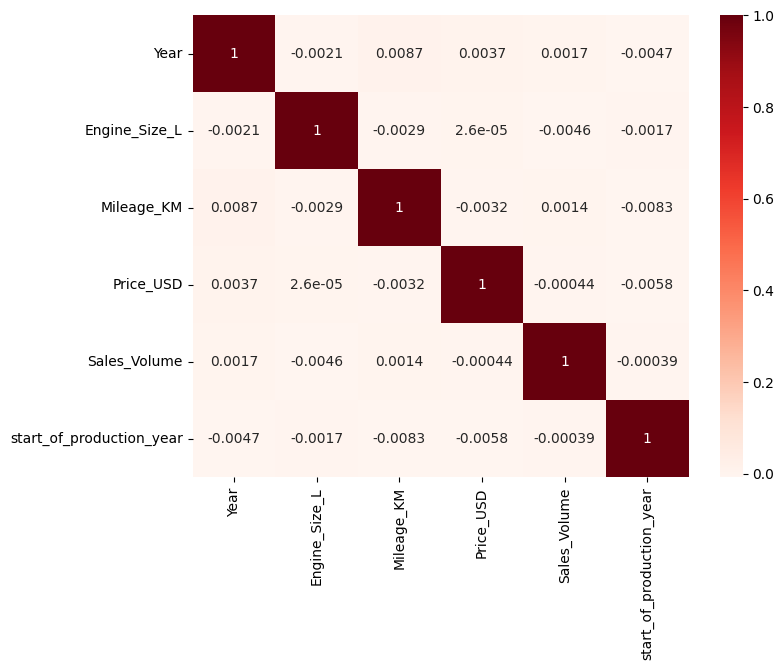

In [93]:
plt.figure(figsize=(8,6))
cor1 = data_to_model.corr()
sns.heatmap(cor1, annot=True, cmap=plt.cm.Reds)
plt.show()

In [95]:
features = data_to_model.iloc[:,1:3]
target = data_to_model.iloc[:,-2]
 
scaler = StandardScaler()
features = scaler.fit_transform(features)
 
X_train, X_valid, y_train, y_valid = train_test_split(
    features, target, test_size=0.2, random_state=2023)
print(X_train.shape, X_valid.shape)

(38147, 2)
(9537, 2)

In [96]:
random.seed(100)
rf = RandomForestRegressor(n_estimators=1000, random_state=100)
rf.fit(X_train, y_train)

,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
y_pred=rf.predict(X_valid)

In [98]:
rf.score(X_train,y_train)

0.8287965890684028

In [99]:
print(mean_squared_error(y_valid, y_pred))
print(mean_absolute_error(y_valid, y_pred))

10458625.35038009

2722.0567850118

In [100]:
reg = GradientBoostingRegressor(random_state=0)

In [101]:
reg.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [102]:
reg.score(X_train,y_train)

0.010962631535965661

In [103]:
y_pred_r=reg.predict(X_valid)

In [104]:
print(mean_squared_error(y_valid, y_pred_r))
print(mean_absolute_error(y_valid, y_pred_r))

8317500.218671685

2506.4173346096372

features = data_to_model.iloc[:,1:-1]
target = data_to_model.iloc[:,0]
 
scaler = StandardScaler()
features = scaler.fit_transform(features)
 
X_train, X_valid, y_train, y_valid = train_test_split(
    features, target, test_size=0.3, random_state=1023)
print(X_train.shape, X_valid.shape)

In [ ]:
random.seed(100)
rfc = RandomForestClassifier(n_estimators=1000, random_state=100)
rfc.fit(X_train, y_train)

In [ ]:
y_pred=rfc.predict(X_valid)

In [ ]:
rfc.score(X_train,y_train)

do przecztania

https://en.wikipedia.org/wiki/Confusion_matrix

In [105]:
r = sklearn.metrics.confusion_matrix(y_valid, y_pred)
print(r)

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [ ]:
sklearn.metrics.accuracy_score(y_valid, y_pred)

In [ ]:
y_pred

In [ ]:
y_valid.value_counts()

In [106]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

import numpy as np
labels = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,99]
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.hot)
plt.show()

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [ ]:
sklearn.metrics.precision_score(y_valid, y_pred, labels=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,99], average=None) # można też globalnie average micro, macro, weighted

In [ ]:
print(sklearn.metrics.classification_report(y_valid, y_pred, labels=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,99], target_names=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','99']))